In [9]:
# Setup, ground truths
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

SIGMA = 2

# x is a Numpy array of spatial coords
def exact_phi_1(x):
    # Calculates analytical solution for f(x) = x
    # Returns an array eval at \phi_1(x) = c_1 e^{2x} + c_2 e^{-2x} + \frac{x}{4} using derived bound. condition consts
    c1 = 1.0 / (8.0 *(1.0 - np.exp(2.0)))
    c2 = 1.0 / (8.0 * (1.0 - np.exp(-2.0)))

    phi = c1 * np.exp(2.0 * x) + c2 * np.exp(-2.0 * x) + x / 4.0

    return phi




def exact_phi_2(x):
    # Calculates analytical solution for f(x) = sin(\pi x)
    # Returns an array eval at \phi_1(x) = c_1 e^{2x} + c_2 e^{-2x} + \frac{1}{\pi^2 + 4} sin(\pi x)

    c1 = -np.pi / (2*(np.pi ** 2.0 + 4.0) * (1.0 - np.exp(2.0)))
    c2 = np.pi / (2*(np.pi ** 2.0 + 4.0) * (1.0 - np.exp(-2.0)))

    phi = c1 * np.exp(2.0 * x) + c2 * np.exp(-2.0 * x) + (1.0 / (np.pi ** 2.0 + 4.0)) * np.sin(np.pi * x)

    return phi

In [10]:
# Method 3: Green's Function Solver
# N is the number of grid points, exact_sol_func is exact soln, rhs_func is the rhs i.e. f(x) = x
def solve_bvp_greens(N, exact_sol_func, rhs_func):
    # Step size and grid
    h = 1.0 / N
    x = np.arange(N) * h

    # Eval of rhs func on grid
    f_val = rhs_func(x)

    # First column of the circulant matrix G (evaluated at y=0)
    # Uses the global SIGMA = 2 defined in your setup cell
    gc = h * np.cosh(SIGMA * (np.abs(x) - 0.5)) / (2.0 * SIGMA * np.sinh(SIGMA / 2.0))

    # Computing numerical soln using fast convolution: u = F_N^* D F_N f
    # D is effectively represented by np.fft.fft(gc)
    # np.fft.ifft natively handles the 1/N scaling factor
    u = np.real(np.fft.ifft(np.fft.fft(gc) * np.fft.fft(f_val)))

    # append per. bound point for plotting(phi(1) = phi(0))
    x_plot = np.append(x, 1.0)
    u_plot = np.append(u, u[0])

    # eval exact soln on extended grid
    exact_plot = exact_sol_func(x_plot)

    # calculate max abs error across grid
    max_error = np.max(np.abs(exact_plot - u_plot))

    return x_plot, u_plot, exact_plot, h, max_error

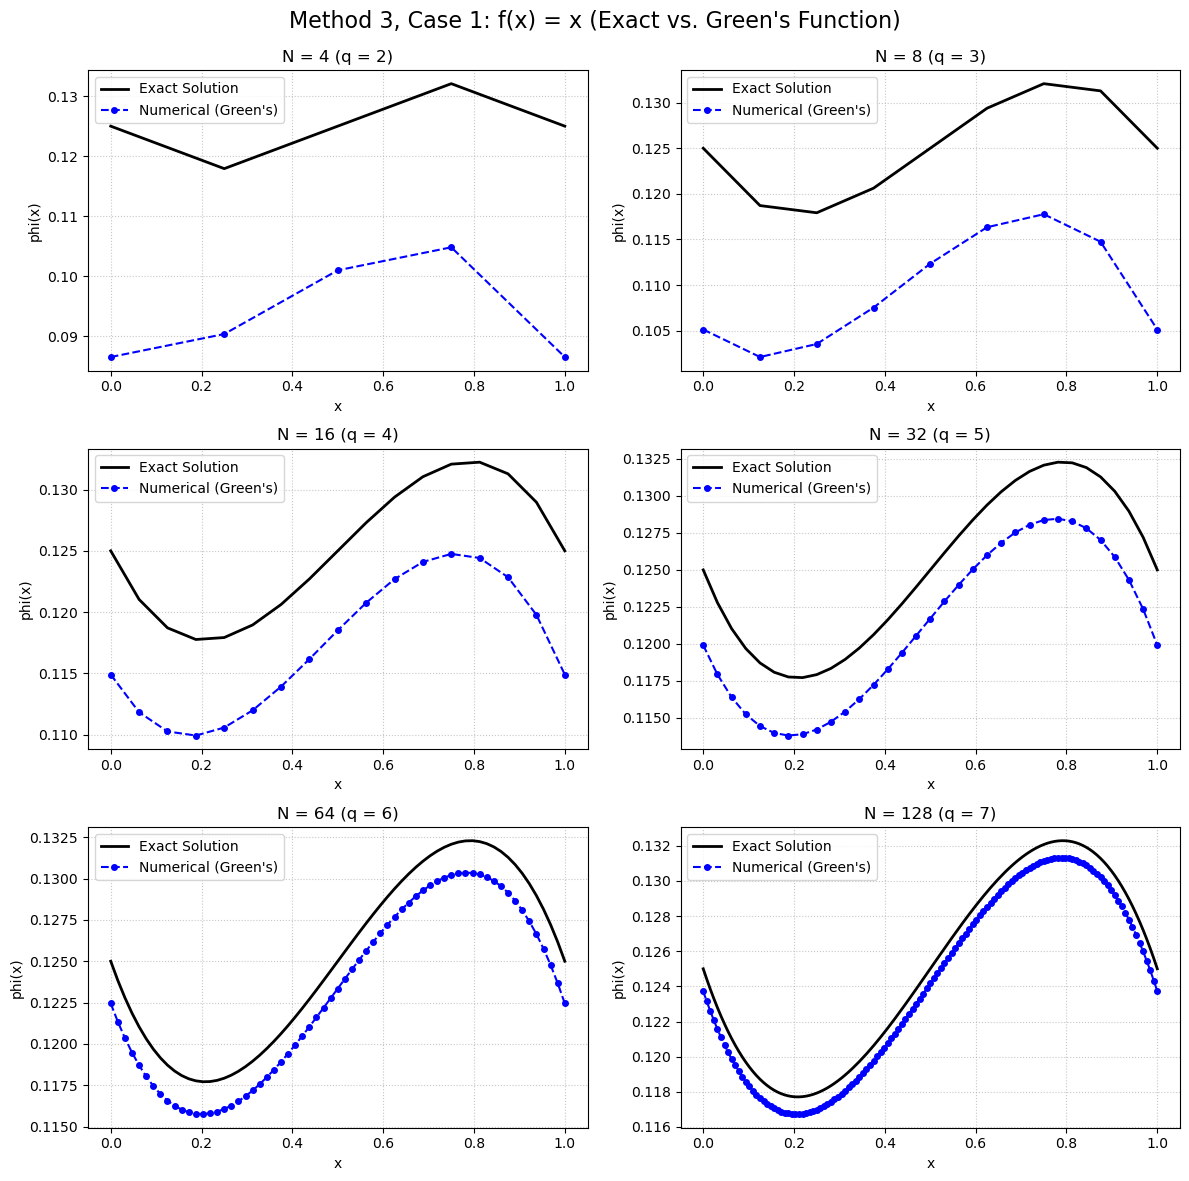

,h,max |phi_n - u_n|,max |phi_n - u_n| / h,max |phi_n - u_n| / h^2
0,0.250000,0.038439,0.153756,0.615024
1,0.125000,0.019866,0.158926,1.271412
2,0.062500,0.010095,0.161526,2.584415
3,0.031250,0.005088,0.162827,5.210477
4,0.015625,0.002554,0.163478,10.462616
5,0.007812,0.001280,0.163804,20.966898


In [11]:
# Executing/Plotting Case 1 for Method 3
results_case1_m3 = []

def rhs_func_1(x):
    return x

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Method 3, Case 1: f(x) = x (Exact vs. Green's Function)", fontsize=16)

for i, q in enumerate(range(2, 8)):
    N = 2 ** q

    # Run Green's Function solver
    x_plot, u_plot, exact_plot, h, max_error = solve_bvp_greens(N, exact_phi_1, rhs_func_1)

    # Map loop index to 3x2 grid coordinates
    row = i // 2
    col = i % 2
    ax = axs[row, col]

    # Plot exact + numerical solutions
    ax.plot(x_plot, exact_plot, 'k-', label="Exact Solution", linewidth=2)
    ax.plot(x_plot, u_plot, 'b--', label="Numerical (Green's)", marker='o', markersize=4)
    
    # Make subplot look nice
    ax.set_title(f"N = {N} (q = {q})")
    ax.set_xlabel("x")
    ax.set_ylabel("phi(x)")
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

    # Get the metrics for data table
    results_case1_m3.append({
        "h": h,
        "max |phi_n - u_n|": max_error,
        "max |phi_n - u_n| / h": max_error / h,
        "max |phi_n - u_n| / h^2": max_error / (h ** 2.0)
    })

# Format, show figure
plt.tight_layout()
fig.subplots_adjust(top=0.93)
plt.show()

# Create, display the error table using Pandas
df_case1_m3 = pd.DataFrame(results_case1_m3)
df_case1_m3

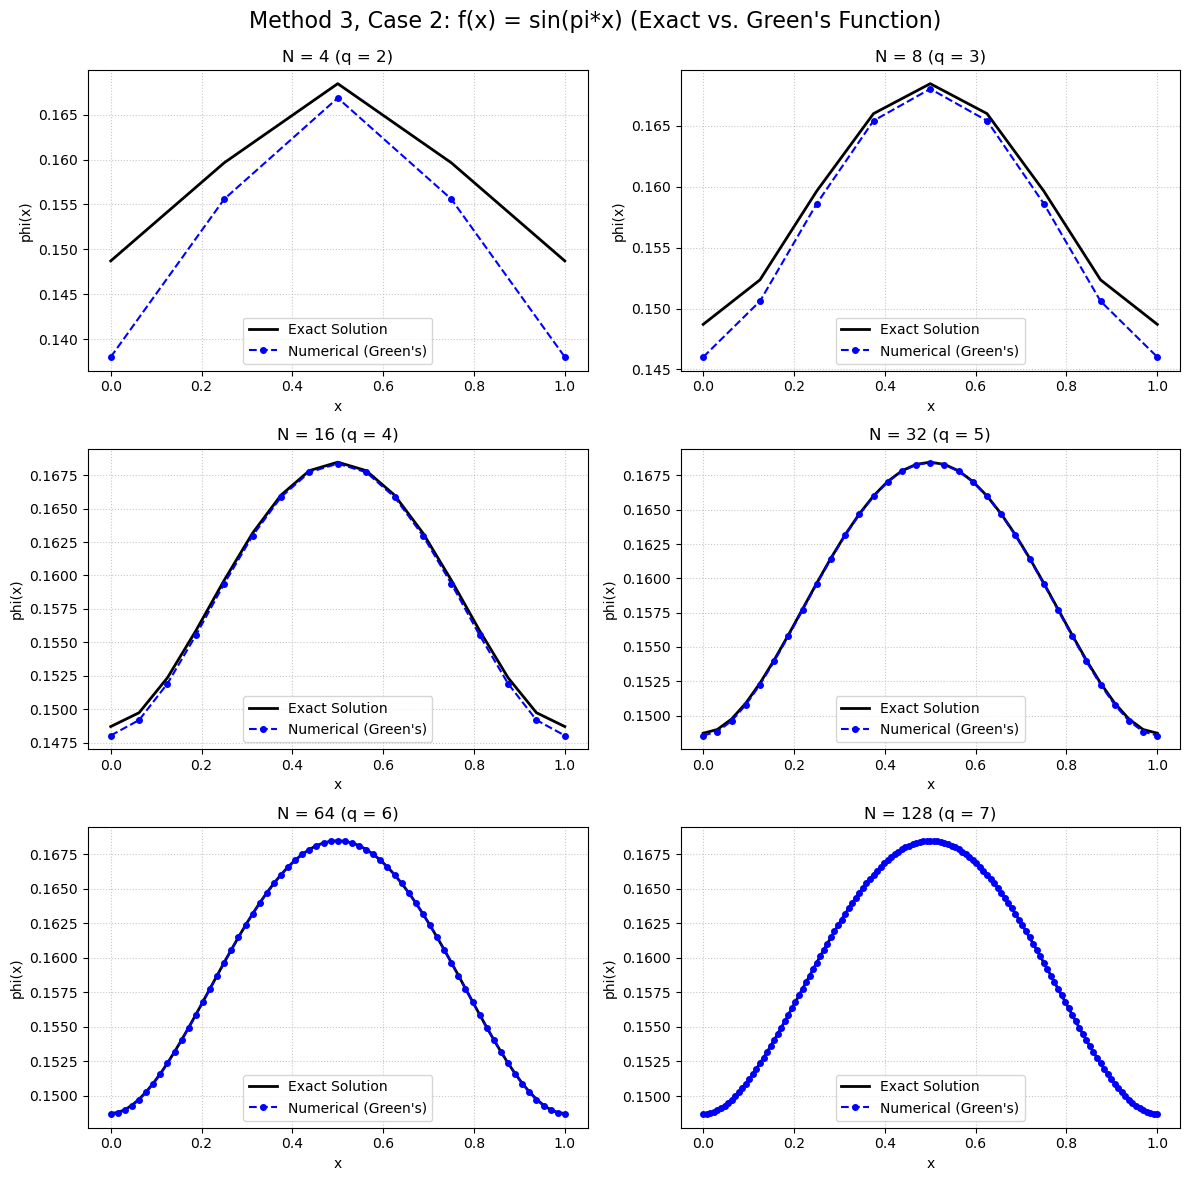

,h,max |phi_n - u_n|,max |phi_n - u_n| / h,max |phi_n - u_n| / h^2
0,0.250000,0.010715,0.042859,0.171436
1,0.125000,0.002684,0.021472,0.171777
2,0.062500,0.000671,0.010741,0.171852
3,0.031250,0.000168,0.005371,0.171870
4,0.015625,0.000042,0.002686,0.171874
5,0.007812,0.000010,0.001343,0.171876


In [12]:
# Executing/Plotting Case 2 for Method 3
def rhs_func_2(x):
    return np.sin(np.pi * x)

results_case2_m3 = []

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle("Method 3, Case 2: f(x) = sin(pi*x) (Exact vs. Green's Function)", fontsize=16)

for i, q in enumerate(range(2, 8)):
    N = 2 ** q

    # Run Green's Function solver
    x_plot, u_plot, exact_plot, h, max_error = solve_bvp_greens(N, exact_phi_2, rhs_func_2)

    # Map loop index to 3x2 grid coordinates
    row = i // 2
    col = i % 2
    ax = axs[row, col]

    # Plot exact + numerical solutions
    ax.plot(x_plot, exact_plot, 'k-', label="Exact Solution", linewidth=2)
    ax.plot(x_plot, u_plot, 'b--', label="Numerical (Green's)", marker='o', markersize=4)

    # Make subplot look nice
    ax.set_title(f"N = {N} (q = {q})")
    ax.set_xlabel("x")
    ax.set_ylabel("phi(x)")
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()

    # Get the metrics for data table
    results_case2_m3.append({
        "h": h,
        "max |phi_n - u_n|": max_error,
        "max |phi_n - u_n| / h": max_error / h,
        "max |phi_n - u_n| / h^2": max_error / (h ** 2.0)
    })

# Format, show figure
plt.tight_layout()
fig.subplots_adjust(top=0.93)
plt.show()

# Create, display the error table using Pandas
df_case2_m3 = pd.DataFrame(results_case2_m3)
df_case2_m3

Although this comes from from an exact analytical integral/computed using precise FFT, this one unexpectedly plateaus at second-order accuracy for both test cases. This happens since the theoretical Green's function contains a sharp "kink" or a jump discontinuity in its first derivative—precisely where x = y. Integrating across this non-smooth point inherently restricts the riemann sums accuracy,bottlenecking the whole method regardless of how smooth the forcing function is